In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()





In [3]:
# fixing date data from str to date object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'], errors='coerce')

In [4]:
# iloc only accepts int as input so can not give column name
df.iloc[:,5]

0         False
1         False
2         False
3         False
4         False
          ...  
785736    False
785737    False
785738    False
785739    False
785740    False
Name: job_work_from_home, Length: 785741, dtype: bool

In [5]:
# loc accepts str so column name for filtering
df.loc[(df['job_posted_date'] > '2023-08-01') & (df['job_title_short'] != 'Data Analyst'), ['job_title_short', 'job_posted_date']]

,job_title_short,job_posted_date
2,Data Engineer,2023-10-10 13:14:55
4,Data Engineer,2023-08-07 14:29:36
5,Data Engineer,2023-11-07 14:01:59
7,Data Engineer,2023-12-07 13:40:49
11,Data Engineer,2023-11-03 13:06:51
...,...,...
785686,Business Analyst,2023-11-20 06:20:34
785696,Senior Data Scientist,2023-10-23 06:31:25
785698,Data Engineer,2023-08-09 06:32:00
785701,Data Engineer,2023-08-09 06:31:57


In [6]:
df.loc[0:10, 'job_work_from_home': 'job_posted_date']

,job_work_from_home,search_location,job_posted_date
0,False,"Texas, United States",2023-06-16 13:44:15
1,False,Mexico,2023-01-14 13:18:07
2,False,Germany,2023-10-10 13:14:55
3,False,"Texas, United States",2023-07-04 13:01:41
4,False,Sudan,2023-08-07 14:29:36
5,True,Georgia,2023-11-07 14:01:59
6,False,"Florida, United States",2023-03-27 13:18:18
7,True,Romania,2023-12-07 13:40:49
8,False,Denmark,2023-06-05 13:44:34
9,True,"New York, United States",2023-04-23 13:02:57


In [7]:
df.loc[:, 'salary_rate': 'salary_year_avg'].dropna(subset='salary_year_avg').sort_values(by='salary_year_avg', ascending=False)

,salary_rate,salary_year_avg
554784,year,960000.0
665811,year,890000.0
168402,year,650000.0
387378,year,585000.0
160521,year,550000.0
...,...,...
213687,year,24000.0
535260,year,23496.0
130855,year,20000.0
380187,year,16500.0


In [8]:
# the same as above, but first sorting then removing nan values
df.loc[:, 'salary_rate': 'salary_year_avg'].sort_values(by='salary_year_avg', ascending=False).dropna(subset='salary_year_avg')

,salary_rate,salary_year_avg
554784,year,960000.0
665811,year,890000.0
168402,year,650000.0
387378,year,585000.0
160521,year,550000.0
...,...,...
213687,year,24000.0
535260,year,23496.0
130855,year,20000.0
380187,year,16500.0


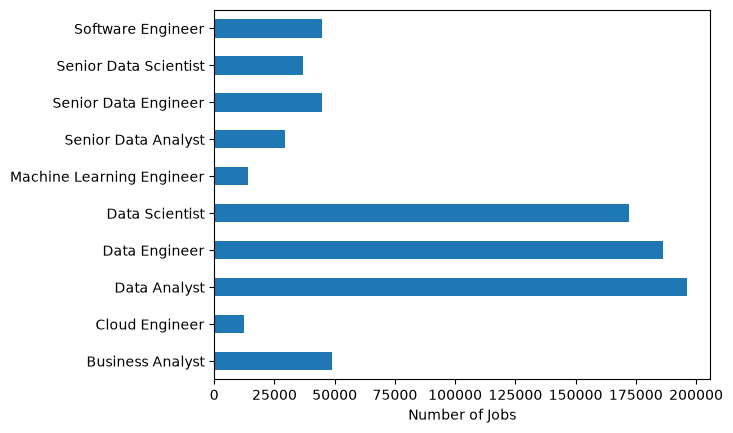

In [9]:
job_counts = df.groupby('job_title_short')['job_title_short'].count()
job_counts.plot(kind='barh')

plt.ylabel('')
plt.xlabel('Number of Jobs')
#plt.title('Number of Job Postings by Job Title')
plt.show()

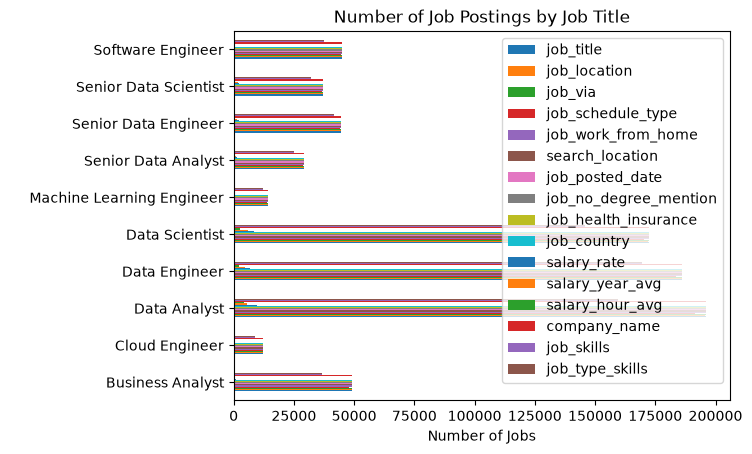

In [10]:
job_counts = df.groupby('job_title_short').count()
job_counts.plot(kind='barh')

plt.ylabel(' ')
plt.xlabel('Number of Jobs')
plt.title('Number of Job Postings by Job Title')
plt.show()

In [11]:
# the median method handles nan values itself
median_year_salary = df['salary_year_avg'].median()
median_year_salary_1 = df['salary_year_avg'].dropna().median()
print(median_year_salary)
print(median_year_salary_1)

115000.0
115000.0


In [12]:
# replacing nan salary with median salary

df_repalced_nan = df
df_repalced_nan['salary_year_avg'] = df_repalced_nan['salary_year_avg'].fillna(median_year_salary)
df_repalced_nan['salary_hour_avg'] = df_repalced_nan['salary_hour_avg'].fillna(median_year_salary)
#df_repalced_nan['salary_year_avg'].fillna(median_year_salary, , inplace= True)
#inplace=True opton does not work as it works on a copy version of data so it says i can not change the original data
df_repalced_nan[['salary_hour_avg','salary_year_avg']]

,salary_hour_avg,salary_year_avg
0,115000.0,115000.0
1,115000.0,115000.0
2,115000.0,115000.0
3,115000.0,115000.0
4,115000.0,115000.0
...,...,...
785736,115000.0,115000.0
785737,115000.0,115000.0
785738,115000.0,115000.0
785739,115000.0,115000.0


In [13]:
df_unique = df_repalced_nan
df_unique = df_unique.drop_duplicates()
print("Number of rows of df_repalced_nan: ", len(df_repalced_nan))
print("Number of rows of df_unique: ", len(df_unique))
print("Number of droped rows: ", len(df_repalced_nan)-len(df_unique))

Number of rows of df_repalced_nan:  785741
Number of rows of df_unique:  785640
Number of droped rows:  101


In [18]:
print(id(df))
print(id(df_repalced_nan))
print(id(df_unique))
print(df[['salary_hour_avg','salary_year_avg']])
# this is why we should use df_repalced_nan = df.copy() instead of df_repalced_nan = df and with the df_repalced_nan = df method, both are 
# refering to the same data frame while df_repalced_nan = df.copy() really creates a new copy
df_copy = df.copy()

2493061004464
2493061004464
2491354674496
        salary_hour_avg  salary_year_avg
0              115000.0         115000.0
1              115000.0         115000.0
2              115000.0         115000.0
3              115000.0         115000.0
4              115000.0         115000.0
...                 ...              ...
785736         115000.0         115000.0
785737         115000.0         115000.0
785738         115000.0         115000.0
785739         115000.0         115000.0
785740         115000.0         115000.0

[785741 rows x 2 columns]


Create Sample from data

In [16]:
#creates random samples from data with 3 rows
df.sample(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
377386,Data Engineer,Data Engineer Expert,Anywhere,via LinkedIn,Full-time,True,Ireland,2023-03-30 18:27:54,False,False,Ireland,NaN,115000.0,115000.0,Globant,"['sql', 'python', 'java', 'scala', 'nosql', 'm...","{'analyst_tools': ['power bi', 'tableau'], 'cl..."
694055,Data Analyst,German speaking Data Analyst,"Mannheim, Germany",via BeBee,Full-time,False,Germany,2023-10-01 10:12:55,True,False,Germany,NaN,115000.0,115000.0,Amadeus FiRe AG,"['sql', 'sql server']","{'databases': ['sql server'], 'programming': [..."
580885,Data Engineer,Cloud Operations Engineer Dataplatform,"Amstelveen, Netherlands",via LinkedIn,Full-time,False,Netherlands,2023-07-12 09:17:30,True,False,Netherlands,NaN,115000.0,115000.0,SVB Sociale Verzekeringsbank,"['powershell', 'bash', 'python', 'azure', 'mic...","{'cloud': ['azure'], 'programming': ['powershe..."


In [17]:
#keeping the same sample from data , 42 has a historical background, other than that it means nothing
df.sample(3,random_state=42)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
502901,Senior Data Engineer,Senior Data Engineer,"St Paul, MN",via BeBee,Full-time,False,"Florida, United States",2023-12-17 11:09:06,False,False,United States,NaN,115000.0,115000.0,ManpowerGroup,"['sql', 'azure', 'git']","{'cloud': ['azure'], 'other': ['git'], 'progra..."
406337,Senior Data Scientist,Senior Analytics Engineer,"London, UK",via LinkedIn,Full-time,False,United Kingdom,2023-10-06 16:09:56,False,False,United Kingdom,NaN,115000.0,115000.0,Harnham,"['sql', 'python', 'bigquery', 'snowflake', 'lo...","{'analyst_tools': ['looker'], 'cloud': ['bigqu..."
659951,Data Engineer,Data Engineer,"Newcastle upon Tyne, UK",via Indeed,Full-time,False,United Kingdom,2023-09-06 10:11:25,True,False,United Kingdom,NaN,115000.0,115000.0,Morgan King,NaN,NaN
